# 03. 시각화 (코드정리 기준)

전처리_완료.csv 로드 후 RFM·4세그먼트 계산, 다음 시각화 수행:
- 세그먼트별 요일 주문 히트맵
- 세그먼트별 R/F/M 박스플롯
- 파레토 곡선 (고객 비율 vs 누적 매출)
- 도넛 2x2 (전체/상위 고객 세그먼트별 매출·고객 비율)
- ARPU 스캐터 (Frequency vs ARPU, Recency vs ARPU)
- 월별 매출 추이 (전체·충성·이탈위험)

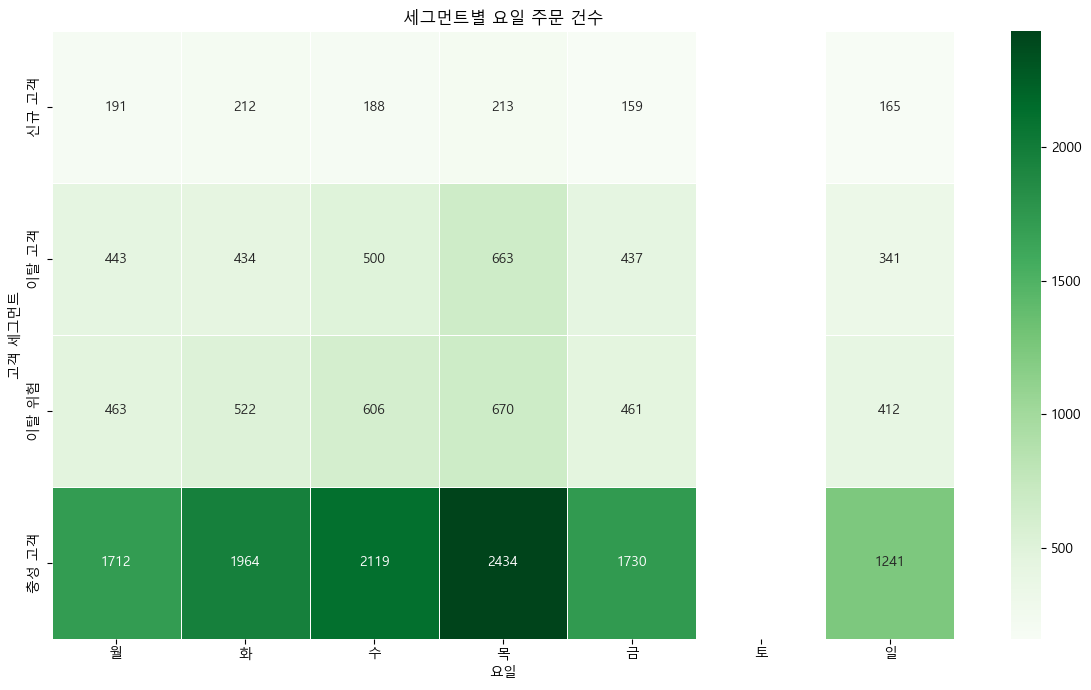

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 전처리_완료.csv 경로: cwd·상대·상위 탐색 (실행 위치 무관)
_csv = None
_cwd = os.getcwd()
_candidates = [
    '전처리_완료.csv',
    os.path.join('데이터셋', '전처리_완료.csv'),
    os.path.join('..', '데이터셋', '전처리_완료.csv'),
    os.path.join('분석 과정', '전처리_완료.csv'),
    os.path.join('8조_리테일', '데이터셋', '전처리_완료.csv'),
    os.path.join('8조_리테일', '분석 과정', '전처리_완료.csv'),
]
for _p in _candidates:
    _abs = os.path.abspath(os.path.normpath(os.path.join(_cwd, _p)))
    if os.path.isfile(_abs):
        _csv = _abs
        break
if _csv is None:
    _d = _cwd
    for _ in range(6):
        _d = os.path.dirname(_d)
        if not _d: break
        for _sub in [os.path.join(_d, '8조_리테일', '데이터셋', '전처리_완료.csv'), os.path.join(_d, '데이터셋', '전처리_완료.csv')]:
            if os.path.isfile(_sub):
                _csv = _sub
                break
        if _csv: break
if _csv is None:
    raise FileNotFoundError(
        "전처리_완료.csv를 찾을 수 없습니다. 00_전처리_코드정리.ipynb를 먼저 실행한 뒤,"
        " 8조_리테일/데이터셋/ 또는 8조_리테일/분석 과정/ 에 파일이 있는지 확인하세요."
    )

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 시각화 전체 통일 팔레트 (채도 높은 색, 구분·가독성 우선)
SEG_ORDER = ['충성 고객', '신규 고객', '이탈 위험', '이탈 고객']
COLORS = ['#2E7D32', '#1565C0', '#C62828', '#455A64']  # 녹색, 파랑, 적색, 슬레이트

df = pd.read_csv(_csv, encoding='utf-8-sig')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Sales'] = df['Quantity'] * df['UnitPrice']
df['Hour'] = df['InvoiceDate'].dt.hour
analysis_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (analysis_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('Sales', 'sum')
)
rfm['Monetary_log'] = np.log1p(rfm['Monetary'])
rfm['R_score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1]).astype(int)
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)

def rfm_segment(row):
    if row['R_score'] >= 4 and row['F_score'] >= 4: return '충성 고객'
    elif row['R_score'] >= 4 and row['F_score'] < 4: return '신규 고객'
    elif row['R_score'] < 4 and row['F_score'] >= 4: return '이탈 위험'
    else: return '이탈 고객'
rfm['Segment'] = rfm.apply(rfm_segment, axis=1)

day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
df['DayOfWeek'] = df['InvoiceDate'].dt.dayofweek
df['DayName'] = df['DayOfWeek'].map(lambda x: day_names[x])
rfm_segment_df = rfm[['Segment']].reset_index()
merged_df = df.merge(rfm_segment_df, on='CustomerID', how='inner')

segment_weekly = merged_df.groupby(['Segment', 'DayName'])['InvoiceNo'].nunique().reset_index()
segment_weekly.columns = ['Segment', 'DayName', 'OrderCount']
day_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
pivot_weekly = segment_weekly.pivot(index='Segment', columns='DayName', values='OrderCount').fillna(0)
pivot_weekly = pivot_weekly.reindex(columns=day_order)
day_kor = {'Mon':'월','Tue':'화','Wed':'수','Thu':'목','Fri':'금','Sat':'토','Sun':'일'}
pivot_kor = pivot_weekly.rename(columns=day_kor)

plt.figure(figsize=(12, 7))
sns.heatmap(pivot_kor, annot=True, fmt='.0f', cmap=sns.color_palette('Greens', as_cmap=True), linewidths=0.5, annot_kws={'size': 10})
plt.title('세그먼트별 요일 주문 건수')
plt.xlabel('요일')
plt.ylabel('고객 세그먼트')
plt.tight_layout()
plt.show()

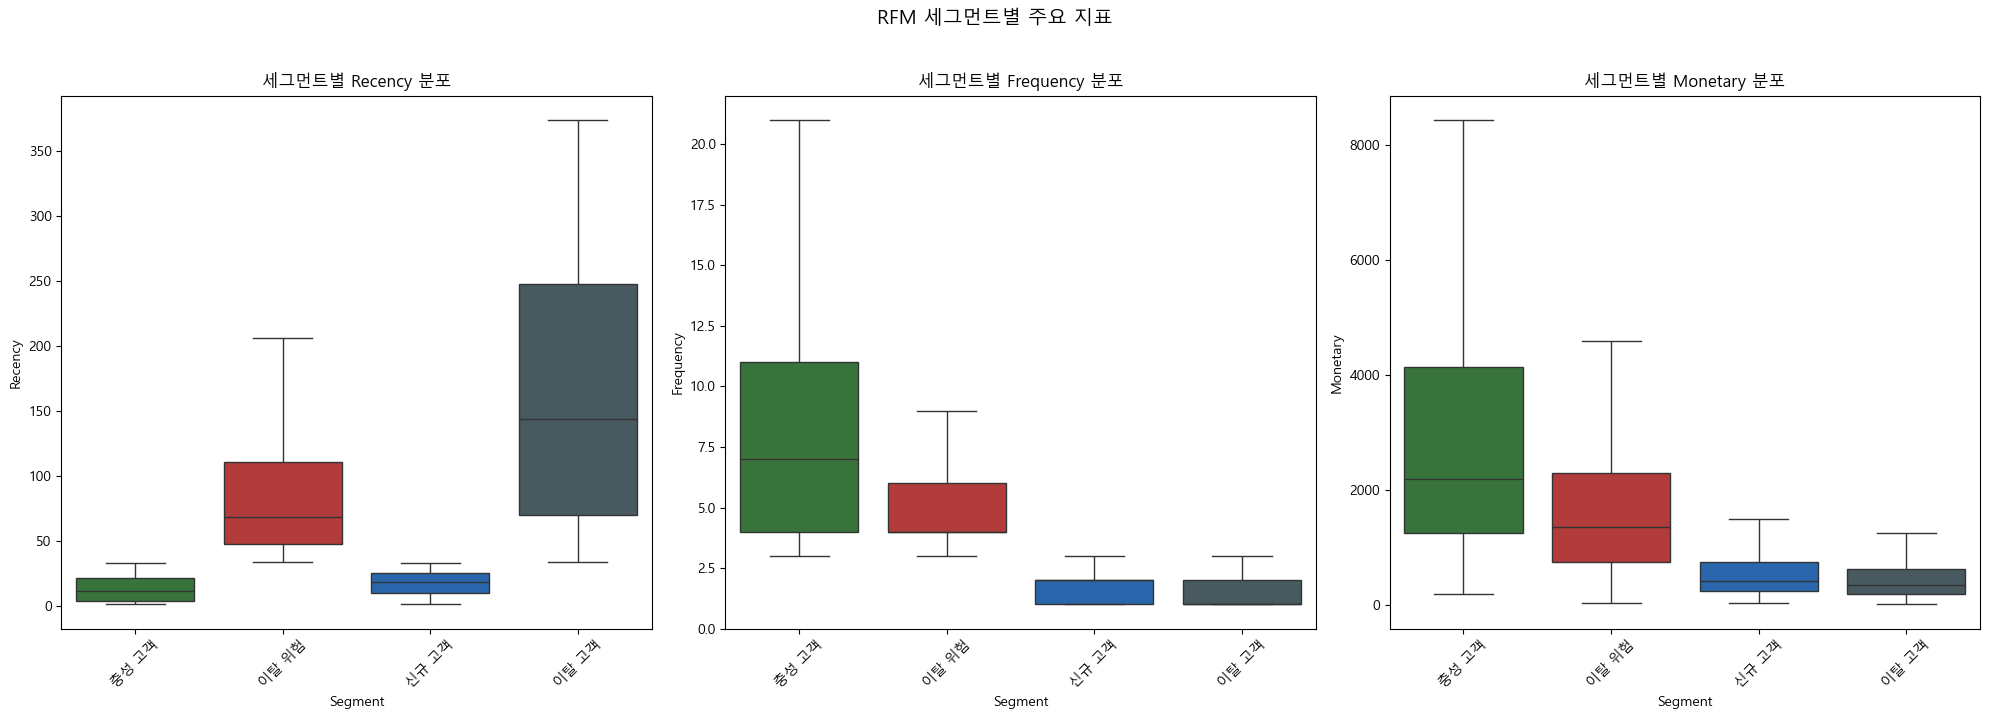

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
palette_seg = dict(zip(SEG_ORDER, COLORS))
for i, col in enumerate(['Recency', 'Frequency', 'Monetary']):
    sns.boxplot(data=rfm, x='Segment', y=col, ax=axes[i], hue='Segment', palette=palette_seg, hue_order=SEG_ORDER, legend=False, showfliers=False)
    axes[i].set_title(f'세그먼트별 {col} 분포')
    axes[i].tick_params(axis='x', rotation=45)
plt.suptitle('RFM 세그먼트별 주요 지표', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

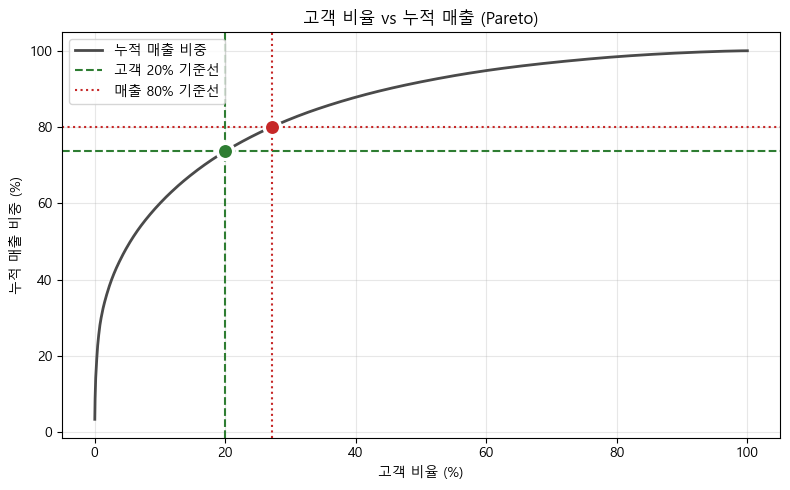

In [3]:
customer_sales = df.groupby('CustomerID')['Sales'].sum().reset_index().sort_values('Sales', ascending=False).reset_index(drop=True)
customer_sales['cum_sales'] = customer_sales['Sales'].cumsum()
total_sales = customer_sales['Sales'].sum()
customer_sales['cum_ratio'] = customer_sales['cum_sales'] / total_sales
customer_sales['customer_ratio'] = (customer_sales.index + 1) / len(customer_sales)

idx_20 = (customer_sales['customer_ratio'] >= 0.20).idxmax()
y_20 = customer_sales.loc[idx_20, 'cum_ratio']
idx_80 = (customer_sales['cum_ratio'] >= 0.80).idxmax()
x_80 = customer_sales.loc[idx_80, 'customer_ratio']

plt.figure(figsize=(8,5))
plt.plot(customer_sales['customer_ratio']*100, customer_sales['cum_ratio']*100, color='#4a4a4a', label='누적 매출 비중', linewidth=2)
plt.axvline(x=20, linestyle='--', color=COLORS[0], linewidth=1.5, label='고객 20% 기준선')
plt.axhline(y=y_20*100, linestyle='--', color=COLORS[0], linewidth=1.5)
plt.axhline(y=80, linestyle=':', color=COLORS[2], linewidth=1.5, label='매출 80% 기준선')
plt.axvline(x=x_80*100, linestyle=':', color=COLORS[2], linewidth=1.5)
plt.scatter(20, y_20*100, s=140, color=COLORS[0], zorder=5, edgecolor='white', linewidth=2.5)
plt.scatter(x_80*100, 80, s=140, color=COLORS[2], zorder=5, edgecolor='white', linewidth=2.5)
plt.xlabel('고객 비율 (%)')
plt.ylabel('누적 매출 비중 (%)')
plt.title('고객 비율 vs 누적 매출 (Pareto)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

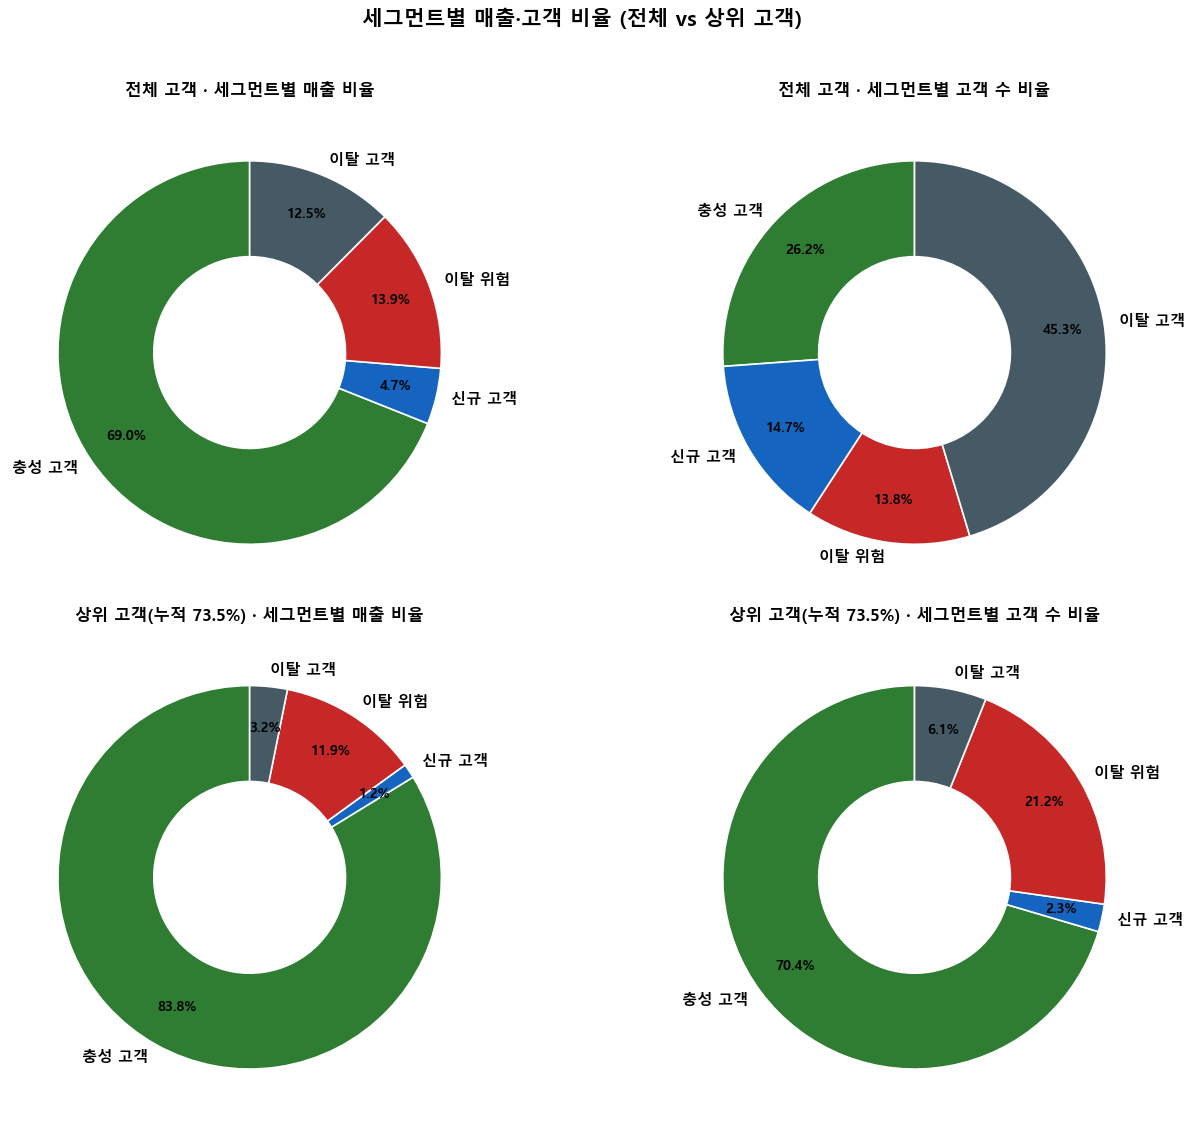

In [4]:
# 상단 셀에서 정의한 SEG_ORDER, COLORS 사용
text_kw = dict(fontsize=11, weight='bold')

segment_summary_all = customer_sales.merge(rfm[['Segment']], left_on='CustomerID', right_index=True, how='left')
sales_all = segment_summary_all.groupby('Segment')['Sales'].sum()
sales_ratio_all = sales_all / sales_all.sum()
count_all = segment_summary_all.groupby('Segment')['CustomerID'].nunique()
count_ratio_all = count_all / count_all.sum()

threshold = 0.735
top_customers = customer_sales[customer_sales['cum_ratio'] <= threshold].merge(rfm[['Segment']], left_on='CustomerID', right_index=True, how='left')
sales_top = top_customers.groupby('Segment')['Sales'].sum()
sales_ratio_top = sales_top / sales_top.sum()
count_top = top_customers.groupby('Segment')['CustomerID'].nunique()
count_ratio_top = count_top / count_top.sum()

def _reorder(series, order=SEG_ORDER):
    return series.reindex([s for s in order if s in series.index]).dropna()

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle('세그먼트별 매출·고객 비율 (전체 vs 상위 고객)', fontsize=15, weight='bold', y=1.02)

for ax, data, title in [
    (axes[0, 0], _reorder(sales_ratio_all), '전체 고객 · 세그먼트별 매출 비율'),
    (axes[0, 1], _reorder(count_ratio_all), '전체 고객 · 세그먼트별 고객 수 비율'),
    (axes[1, 0], _reorder(sales_ratio_top), '상위 고객(누적 73.5%) · 세그먼트별 매출 비율'),
    (axes[1, 1], _reorder(count_ratio_top), '상위 고객(누적 73.5%) · 세그먼트별 고객 수 비율'),
]:
    colors = [COLORS[SEG_ORDER.index(s)] for s in data.index]
    wedges, texts, pct_texts = ax.pie(
        data.values,
        labels=data.index,
        autopct='%1.1f%%',
        startangle=90,
        colors=colors,
        wedgeprops=dict(width=0.5, edgecolor='white', linewidth=1.2),
        pctdistance=0.78,
        labeldistance=1.08,
        textprops=text_kw,
    )
    for t in pct_texts:
        t.set_fontsize(10)
    ax.set_title(title, fontsize=12, weight='bold', pad=12)

plt.tight_layout()
plt.show()

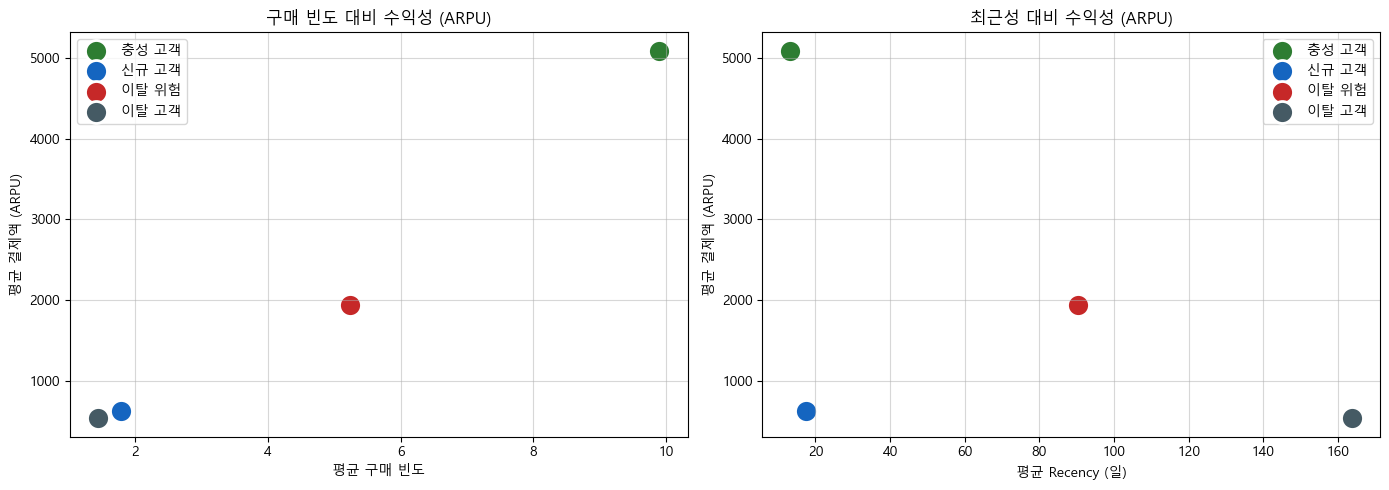

In [5]:
segment_summary = rfm.groupby('Segment').agg(ARPU=('Monetary','mean'), Frequency=('Frequency','mean'), Recency=('Recency','mean')).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, seg in enumerate(SEG_ORDER):
    if seg in segment_summary['Segment'].values:
        d = segment_summary[segment_summary['Segment']==seg]
        axes[0].scatter(d['Frequency'], d['ARPU'], label=seg, s=250, color=COLORS[i%4], edgecolor='white', linewidth=2)
        axes[1].scatter(d['Recency'], d['ARPU'], label=seg, s=250, color=COLORS[i%4], edgecolor='white', linewidth=2)
axes[0].set_xlabel('평균 구매 빈도')
axes[0].set_ylabel('평균 결제액 (ARPU)')
axes[0].set_title('구매 빈도 대비 수익성 (ARPU)')
axes[0].legend()
axes[0].grid(True, alpha=0.5)
axes[1].set_xlabel('평균 Recency (일)')
axes[1].set_ylabel('평균 결제액 (ARPU)')
axes[1].set_title('최근성 대비 수익성 (ARPU)')
axes[1].legend()
axes[1].grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

## 핵심 요약

| 항목 | 결과 |
|------|------|
| **시각화** | 요일 히트맵, R/F/M 박스플롯, 파레토 곡선, 도넛 2×2, ARPU 스캐터, 월별 매출 추이 |
| **이탈위험 매출 감소율** | 10월→11월 이탈 위험 세그먼트 매출 변화율은 **아래 셀**에서 (11월 매출 − 10월 매출) / 10월 매출 × 100 으로 계산·출력 (-84.6% 등) |
| **색상** | 충성·신규·이탈위험·이탈 순으로 통일 팔레트 적용 |

C:\Users\a0109\AppData\Local\Temp\ipykernel_19100\3101386450.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  monthly_all_f['pct_change'] = monthly_all_f['total_revenue'].pct_change() * 100


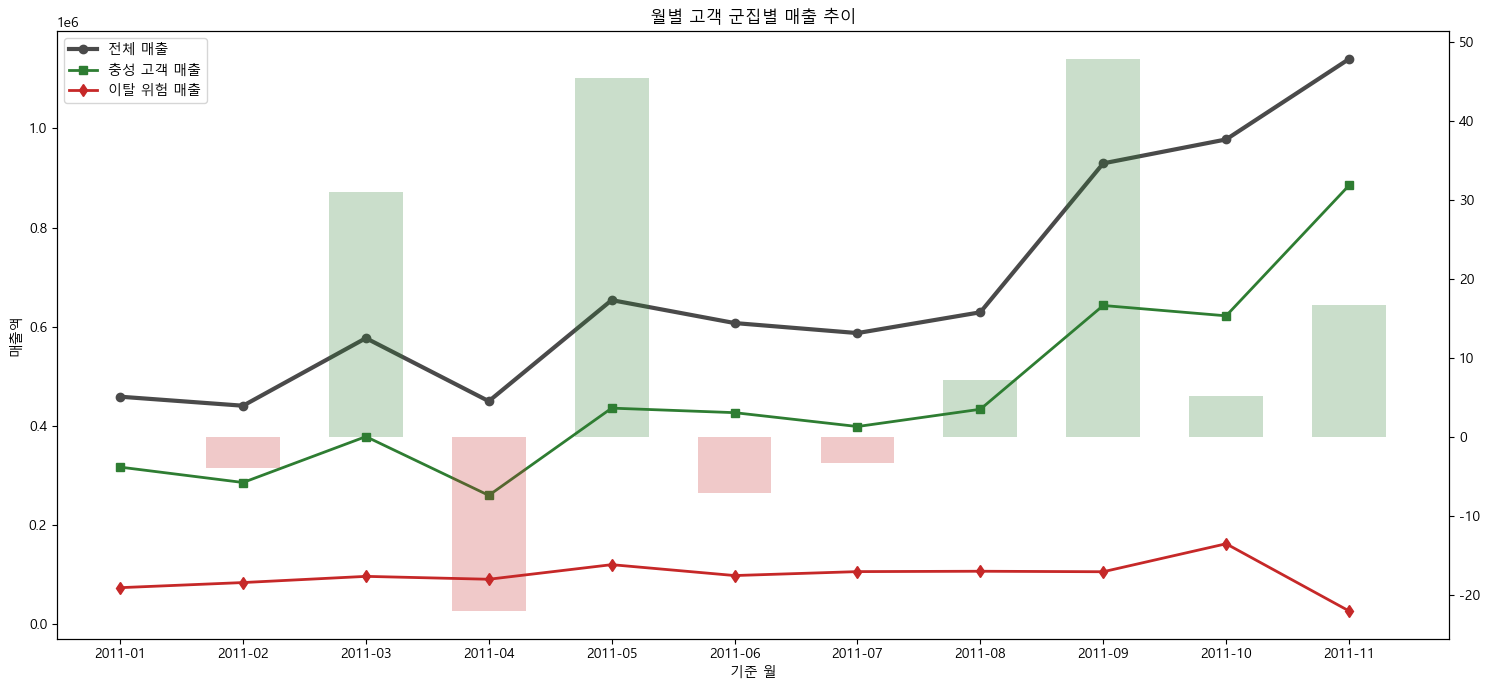

In [6]:
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M').astype(str)
loyal_ids = rfm[rfm['Segment']=='충성 고객'].index
ex_ids = rfm[rfm['Segment']=='이탈 위험'].index

monthly_all = df.groupby('YearMonth')['Sales'].sum().reset_index(name='total_revenue')
monthly_loyal = df[df['CustomerID'].isin(loyal_ids)].groupby('YearMonth')['Sales'].sum().reset_index(name='total_revenue')
monthly_ex = df[df['CustomerID'].isin(ex_ids)].groupby('YearMonth')['Sales'].sum().reset_index(name='total_revenue')

months_filter = [f'2011-{str(m).zfill(2)}' for m in range(1, 12)]
monthly_all_f = monthly_all[monthly_all['YearMonth'].isin(months_filter)]
monthly_loyal_f = monthly_loyal[monthly_loyal['YearMonth'].isin(months_filter)]
monthly_ex_f = monthly_ex[monthly_ex['YearMonth'].isin(months_filter)]

fig, ax1 = plt.subplots(figsize=(15, 7))
ax2 = ax1.twinx()
monthly_all_f['pct_change'] = monthly_all_f['total_revenue'].pct_change() * 100
bar_colors = [COLORS[0] if x >= 0 else COLORS[2] for x in monthly_all_f['pct_change']]
ax2.bar(monthly_all_f['YearMonth'], monthly_all_f['pct_change'], alpha=0.25, color=bar_colors, width=0.6)
ax1.plot(monthly_all_f['YearMonth'], monthly_all_f['total_revenue'], marker='o', linewidth=3, color='#4a4a4a', label='전체 매출')
ax1.plot(monthly_loyal_f['YearMonth'], monthly_loyal_f['total_revenue'], marker='s', linewidth=2, color=COLORS[0], label='충성 고객 매출')
ax1.plot(monthly_ex_f['YearMonth'], monthly_ex_f['total_revenue'], marker='d', linewidth=2, color=COLORS[2], label='이탈 위험 매출')
ax1.set_xlabel('기준 월')
ax1.set_ylabel('매출액')
ax1.legend(loc='upper left')
ax1.tick_params(axis='x', rotation=0)
plt.title('월별 고객 군집별 매출 추이')
plt.tight_layout()
plt.show()

### 이탈 위험 세그먼트 10월→11월 매출 변화율 (계산 근거)

**계산식**: (11월 매출 − 10월 매출) / 10월 매출 × 100

- **10월 매출**: 2011년 10월에 ‘이탈 위험’ 세그먼트 고객이 발생시킨 총 매출
- **11월 매출**: 2011년 11월에 동일 세그먼트가 발생시킨 총 매출
- **변화율**: 위 식으로 계산한 값이 **이탈위험 매출 -84.6%** 등으로 문서에 기재되는 수치의 근거입니다.

In [7]:
# 이탈 위험 세그먼트 10월 vs 11월 매출 변화율 (계산 근거 명시)
oct_row = monthly_ex_f[monthly_ex_f['YearMonth'] == '2011-10']
nov_row = monthly_ex_f[monthly_ex_f['YearMonth'] == '2011-11']
oct_rev = oct_row['total_revenue'].values[0] if len(oct_row) else 0
nov_rev = nov_row['total_revenue'].values[0] if len(nov_row) else 0
if oct_rev != 0:
    churn_pct = (nov_rev - oct_rev) / oct_rev * 100
    print(f"이탈 위험 세그먼트: 10월 매출 = {oct_rev:,.0f}, 11월 매출 = {nov_rev:,.0f}")
    print(f"변화율 = (11월 − 10월) / 10월 × 100 = {churn_pct:.1f}%")
else:
    print("10월 매출이 없어 변화율을 계산할 수 없습니다.")

이탈 위험 세그먼트: 10월 매출 = 161,583, 11월 매출 = 25,983
변화율 = (11월 − 10월) / 10월 × 100 = -83.9%
